# **Problem Statement**


In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Task 2: Predict Future Stock Prices**
Objective:
Use Apple's historical stock market data to predict the next day's closing price using Machine Learning.

# **Import Libraries**

In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# **Load Dataset**

In [53]:
df = pd.read_csv("/content/drive/MyDrive/Apple_stock_data.csv")

df.head()

,Date,Close,High,Low,Open,Volume
0,1980-12-12,0.098485,0.098913,0.098485,0.098485,469033600
1,1980-12-15,0.093347,0.093775,0.093347,0.093775,175884800
2,1980-12-16,0.086495,0.086924,0.086495,0.086924,105728000
3,1980-12-17,0.088636,0.089064,0.088636,0.088636,86441600
4,1980-12-18,0.091206,0.091634,0.091206,0.091206,73449600


# **Dataset Overview**

In [54]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

Shape:
(11276, 6)

Columns:
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

First 5 Rows:
         Date     Close      High       Low      Open     Volume
0  1980-12-12  0.098485  0.098913  0.098485  0.098485  469033600
1  1980-12-15  0.093347  0.093775  0.093347  0.093775  175884800
2  1980-12-16  0.086495  0.086924  0.086495  0.086924  105728000
3  1980-12-17  0.088636  0.089064  0.088636  0.088636   86441600
4  1980-12-18  0.091206  0.091634  0.091206  0.091206   73449600


# **Dataset Information**

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11276 entries, 0 to 11275
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    11276 non-null  object 
 1   Close   11276 non-null  float64
 2   High    11276 non-null  float64
 3   Low     11276 non-null  float64
 4   Open    11276 non-null  float64
 5   Volume  11276 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 528.7+ KB


# **Descriptive Statistics**

In [56]:
df.describe()

,Close,High,Low,Open,Volume
count,11276.000000,11276.000000,11276.000000,11276.000000,1.127600e+04
mean,26.338190,26.604214,26.046548,26.316950,3.115608e+08
std,54.577209,55.116469,53.977051,54.522532,3.338464e+08
min,0.037681,0.038109,0.037681,0.038109,0.000000e+00
25%,0.245083,0.250666,0.239582,0.244928,1.080611e+08
50%,0.463977,0.471379,0.457661,0.463511,2.002448e+08
75%,20.639980,20.868081,20.478935,20.680106,3.913413e+08
max,258.103729,259.179926,256.718662,257.276679,7.421641e+09


# **Missing Values Check**

In [57]:
df.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


# **Convert Date Column**

In [58]:
df['Date'] = pd.to_datetime(df['Date'])

df.head()

,Date,Close,High,Low,Open,Volume
0,1980-12-12,0.098485,0.098913,0.098485,0.098485,469033600
1,1980-12-15,0.093347,0.093775,0.093347,0.093775,175884800
2,1980-12-16,0.086495,0.086924,0.086495,0.086924,105728000
3,1980-12-17,0.088636,0.089064,0.088636,0.088636,86441600
4,1980-12-18,0.091206,0.091634,0.091206,0.091206,73449600


# **Visualize Closing Price Trend**

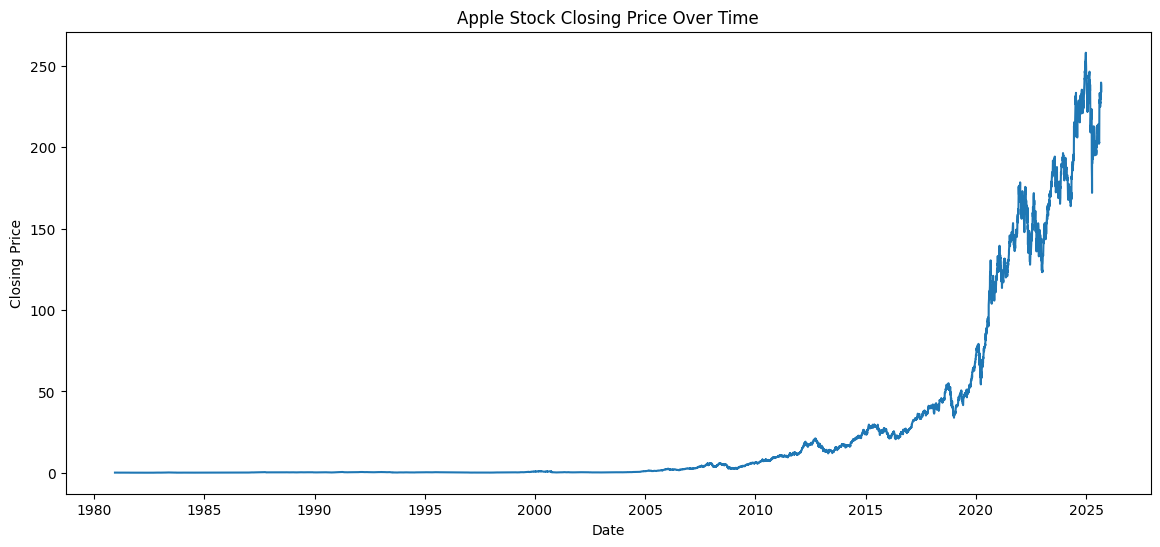

In [59]:
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Close'])

plt.title("Apple Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

# **Correlation Heatmap**

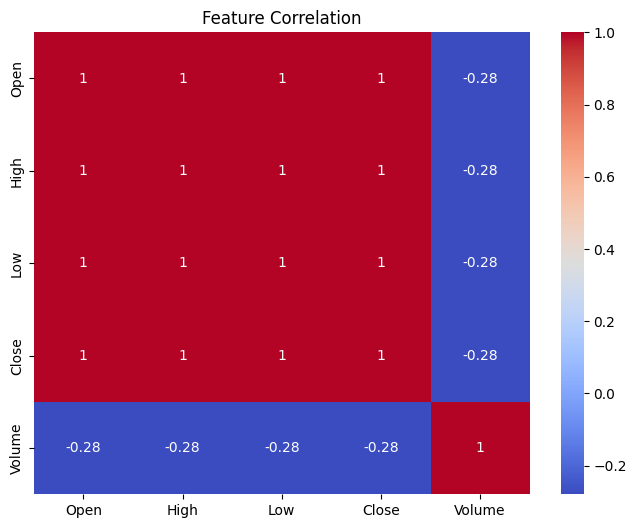

In [60]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Open','High','Low','Close','Volume']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation")
plt.show()

# **Create Target Variable**

df['Next_Close'] = df['Close'].shift(-1)

df.head()

In [61]:
df['Next_Close'] = df['Close'].shift(-1)

df.head()

,Date,Close,High,Low,Open,Volume,Next_Close
0,1980-12-12,0.098485,0.098913,0.098485,0.098485,469033600,0.093347
1,1980-12-15,0.093347,0.093775,0.093347,0.093775,175884800,0.086495
2,1980-12-16,0.086495,0.086924,0.086495,0.086924,105728000,0.088636
3,1980-12-17,0.088636,0.089064,0.088636,0.088636,86441600,0.091206
4,1980-12-18,0.091206,0.091634,0.091206,0.091206,73449600,0.096772


In [62]:
df = df.dropna()

In [63]:
df.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0
Next_Close,0


# **Remove Last Row**

In [64]:
df = df.dropna()

# **Feature Selection**

In [65]:
df['Next_Close'] = df['Close'].shift(-1)
df = df.dropna()
X = df[['Open','High','Low','Volume']]
y = df['Next_Close']

# **Train-Test Split**

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Train Linear Regression Model**

In [67]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## **Predictions**

In [68]:
predictions = model.predict(X_test)

predictions[:5]

array([0.27091202, 0.07150661, 0.7747101 , 0.26325705, 0.12121767])

**Evaluation Metrics**

In [69]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.324436054462841
RMSE: 1.019188119161006
R2 Score: 0.9996231546843496


# **Actual vs Predicted Plot**

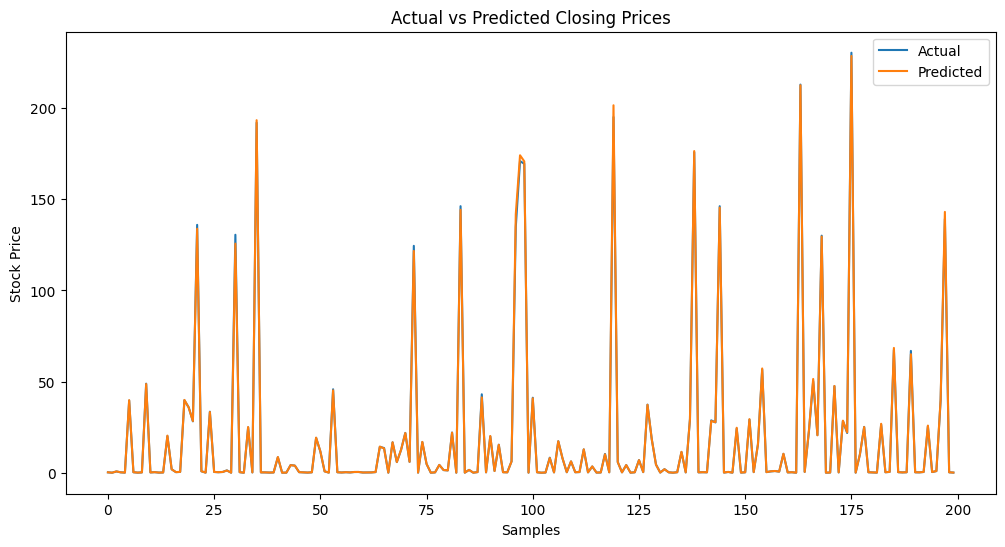

In [70]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:200],
    label="Actual"
)

plt.plot(
    predictions[:200],
    label="Predicted"
)

plt.title("Actual vs Predicted Closing Prices")

plt.xlabel("Samples")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

# **Scatter Plot**

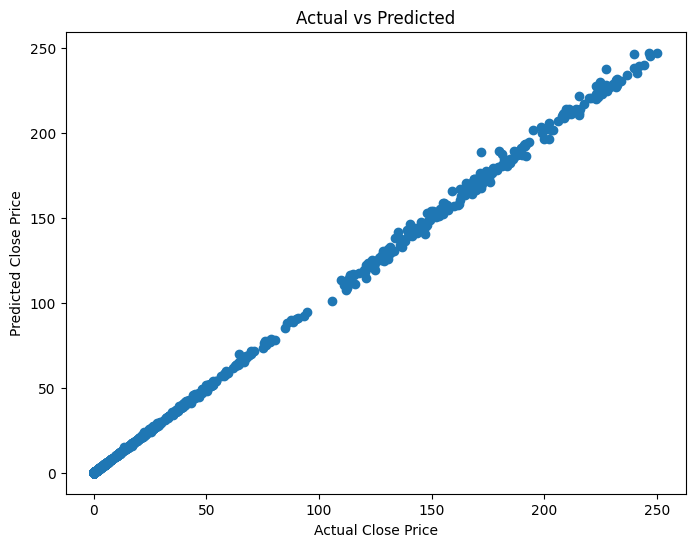

In [71]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")

plt.title("Actual vs Predicted")

plt.show()

## **Feature Importance**

In [72]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance

,Feature,Coefficient
0,Open,-6.206677e-01
1,High,8.086531e-01
2,Low,8.129955e-01
3,Volume,-7.808754e-12


# **Conclusion**

1. Historical Apple stock data was analyzed.
2. Open, High, Low, and Volume were used as features.
3. Linear Regression was trained to predict next-day closing prices.
4. Model achieved a strong R² score.
5. Predicted values closely followed actual stock prices.